In [4]:
!git clone https://github.com/rajatdas-cs/LPG-SAM

fatal: destination path 'LPG-SAM' already exists and is not an empty directory.


In [5]:
%cd LPG-SAM
%mkdir checkpoints

from google.colab import drive
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/data.zip'
extract_path = '/content/LPG-SAM/'

import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

/content/LPG-SAM
mkdir: cannot create directory ‘checkpoints’: File exists
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


KeyboardInterrupt: 

In [3]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

  Preparing metadata (setup.py) ... done


In [4]:
!python -m src.adapter
!python -m src.losses
!python -m src.metrics
!python -m scripts.smoke_test

Device: CUDA: Tesla T4 (15.6 GB)

[1/6] PriorProjector shape check ...
      ok: (2, 1, 1024, 1024) -> (2, 256, 64, 64)
[2/6] FiLMHead shape check ...
      ok: gamma (2, 256, 64, 64), beta (2, 256, 64, 64)
[3/6] TokenHead shape check ...
      ok: tokens (2, 4, 256)
[4/6] LatentPriorAdapter end-to-end shape check ...
[LatentPriorAdapter] trainable: 656.48K / total: 656.48K (100.00%)
      ok: z_mod (2, 256, 64, 64), sparse (2, 4, 256)
[5/6] alpha=0 invariant (z_modulated == z_image) ...
      max |z_mod - z_image| = 0.00e+00
      ok: adapter is a perfect no-op at alpha=0
[6/6] Gradient flow check ...
      ok: alpha.grad = -1.3956e+02

[OK] All adapter checks passed.
Device: CUDA: Tesla T4 (15.6 GB)

[1/4] dice_loss ...
      ok: dice = 0.9587
[2/4] bce_loss ...
      ok: bce  = 0.8035
[3/4] soft_cldice_loss ...
      ok: cldice = 0.9583
[4/4] CompositeLoss + gradient flow ...
      total = 1.1686
      components: dice=0.9587 bce=0.8035 cldice=0.9583
      ok: max |grad| = 2.8717e-0

In [5]:
!python -m scripts.train --config configs/config.yaml

 LPG-SAM training
Config:        configs/config.yaml
Device:        CUDA: Tesla T4 (15.6 GB)
Run dir:       runs/2026-04-29_18-32-08
Log file:      runs/2026-04-29_18-32-08/train.log

[1/4] Loading frozen MedSAM ...
[FrozenSAM] trainable: 0 / total: 93.74M (0.00%)
[2/4] Building LatentPriorAdapter ...
[LatentPriorAdapter] trainable: 656.48K / total: 656.48K (100.00%)
      total trainable params: 656.48K
[3/4] Building datasets ...
      train: 540  val: 60
[4/4] Building loss + optimizer ...
      AMP enabled: True

 Training
epoch 000 | loss 1.067 (dice 0.896 bce 0.334 cld 0.904) | alpha +0.009 | val: dice 0.103 iou 0.055 cld 0.090 b0err 220.48
           ^ new best val clDice = 0.0900
epoch 001 | loss 0.813 (dice 0.693 bce 0.255 cld 0.678) | alpha +0.036 | val: dice 0.540 iou 0.374 cld 0.581 b0err 141.37
           ^ new best val clDice = 0.5811
epoch 002 | loss 0.463 (dice 0.410 bce 0.169 cld 0.348) | alpha +0.060 | val: dice 0.711 iou 0.558 cld 0.763 b0err 145.92
           ^ new 

In [6]:
!python -m scripts.eval \
    --config configs/config.yaml \
    --checkpoint checkpoints/best.pt \
    --dataset-root data/processed/FIVES \
    --split-file data/processed/FIVES/test.txt \
    --tag fives_test

 LPG-SAM evaluation
Config:        configs/config.yaml
Checkpoint:    checkpoints/best.pt
Dataset root:  data/processed/FIVES
Split:         data/processed/FIVES/test.txt
Device:        CUDA: Tesla T4 (15.6 GB)
Output dir:    runs/eval_fives_test_2026-04-29_21-12-38

[1/3] Loading frozen MedSAM ...
[2/3] Loading adapter checkpoint ...
      checkpoint epoch: 26
      checkpoint val:   {'dice': 0.84037040678926, 'iou': 0.7309048963019397, 'cldice': 0.8705494941179432, 'betti0_error': 91.63333333333334, 'n': 60}
      adapter alpha:    +0.1784
[3/3] Building dataset ...
      200 samples

evaluating: 100%|██████████████████████████| 100/100 [02:12<00:00,  1.33s/it, cld=0.829, dice=0.802]

 Results (fives_test)
  n samples:    200
  Dice:         0.8023
  IoU:          0.6824
  clDice:       0.8290    <- headline metric
  Betti-0 err:  84.88

  -> runs/eval_fives_test_2026-04-29_21-12-38/metrics.json
  -> runs/eval_fives_test_2026-04-29_21-12-38/per_image.csv
  -> runs/eval_fives_test_202

In [ ]:
!zip -r /content/LPG-SAM/runs.zip /content/LPG-SAM/runs/

  adding: content/LPG-SAM/runs/ (stored 0%)
  adding: content/LPG-SAM/runs/2026-04-27_19-35-20/ (stored 0%)
  adding: content/LPG-SAM/runs/2026-04-27_19-35-20/config.yaml (deflated 42%)
  adding: content/LPG-SAM/runs/2026-04-27_19-35-20/train.log (deflated 56%)
  adding: content/LPG-SAM/runs/2026-04-27_19-38-57/ (stored 0%)
  adding: content/LPG-SAM/runs/2026-04-27_19-38-57/config.yaml (deflated 42%)
  adding: content/LPG-SAM/runs/2026-04-27_19-38-57/summary.json (deflated 17%)
  adding: content/LPG-SAM/runs/2026-04-27_19-38-57/train.log (deflated 80%)
  adding: content/LPG-SAM/runs/eval_fives_test_2026-04-27_22-13-57/ (stored 0%)
  adding: content/LPG-SAM/runs/eval_fives_test_2026-04-27_22-13-57/overlays/ (stored 0%)
  adding: content/LPG-SAM/runs/eval_fives_test_2026-04-27_22-13-57/overlays/test_100_D.png (deflated 1%)
  adding: content/LPG-SAM/runs/eval_fives_test_2026-04-27_22-13-57/overlays/test_106_G.png (deflated 1%)
  adding: content/LPG-SAM/runs/eval_fives_test_2026-04-27_22-1

In [7]:
!python -m scripts.eval_baseline \
    --config configs/config.yaml \
    --dataset-root data/processed/FIVES \
    --split-file data/processed/FIVES/test.txt \
    --prompt-strategy box \
    --tag fives_baseline_box

 MedSAM zero-shot baseline evaluation
Config:           configs/config.yaml
Dataset root:     data/processed/FIVES
Split:            data/processed/FIVES/test.txt
Prompt strategy:  box
Device:           CUDA: Tesla T4 (15.6 GB)
Output dir:       runs/baseline_fives_baseline_box_2026-04-29_21-21-23

[1/2] Loading frozen MedSAM ...
[2/2] Building dataset ...
      200 samples

baseline (box): 100%|██████████████████████| 100/100 [07:41<00:00,  4.61s/it, cld=0.120, dice=0.141]

 Baseline results (fives_baseline_box, prompt=box)
  n samples:    200
  Dice:         0.1408
  IoU:          0.0762
  clDice:       0.1202    <- headline metric
  Betti-0 err:  40.94

  -> runs/baseline_fives_baseline_box_2026-04-29_21-21-23/metrics.json
  -> runs/baseline_fives_baseline_box_2026-04-29_21-21-23/per_image.csv


In [8]:
!zip -r /content/LPG-SAM/our-eval-and-baseline.zip /content/LPG-SAM/runs/

  adding: content/LPG-SAM/runs/ (stored 0%)
  adding: content/LPG-SAM/runs/2026-04-29_18-32-08/ (stored 0%)
  adding: content/LPG-SAM/runs/2026-04-29_18-32-08/summary.json (deflated 17%)
  adding: content/LPG-SAM/runs/2026-04-29_18-32-08/metrics.csv (deflated 61%)
  adding: content/LPG-SAM/runs/2026-04-29_18-32-08/config.yaml (deflated 43%)
  adding: content/LPG-SAM/runs/2026-04-29_18-32-08/train.log (deflated 80%)
  adding: content/LPG-SAM/runs/baseline_fives_baseline_box_2026-04-29_21-21-23/ (stored 0%)
  adding: content/LPG-SAM/runs/baseline_fives_baseline_box_2026-04-29_21-21-23/metrics.json (deflated 36%)
  adding: content/LPG-SAM/runs/baseline_fives_baseline_box_2026-04-29_21-21-23/per_image.csv (deflated 55%)
  adding: content/LPG-SAM/runs/eval_fives_test_2026-04-29_21-12-38/ (stored 0%)
  adding: content/LPG-SAM/runs/eval_fives_test_2026-04-29_21-12-38/overlays/ (stored 0%)
  adding: content/LPG-SAM/runs/eval_fives_test_2026-04-29_21-12-38/overlays/test_102_G.png (deflated 1%)


In [ ]:
!python -m scripts.eval_baseline \
    --config configs/config.yaml \
    --dataset-root data/processed/FIVES \
    --split-file data/processed/FIVES/test.txt \
    --prompt-strategy grid \
    --grid-n 8 \
    --tag fives_baseline_grid

 MedSAM zero-shot baseline evaluation
Config:           configs/config.yaml
Dataset root:     data/processed/FIVES
Split:            data/processed/FIVES/test.txt
Prompt strategy:  grid
Grid density:     8x8 = 64 prompts/image
Device:           CUDA: Tesla T4 (15.6 GB)
Output dir:       runs/baseline_fives_baseline_grid_2026-04-29_13-55-07

[1/2] Loading frozen MedSAM ...
[2/2] Building dataset ...
      200 samples

baseline (grid 8x8): 100%|█████████████████| 200/200 [05:20<00:00,  1.60s/it, cld=0.167, dice=0.163]

 Baseline results (fives_baseline_grid, prompt=grid)
  n samples:    200
  Dice:         0.1628
  IoU:          0.0892
  clDice:       0.1666    <- headline metric
  Betti-0 err:  210.83

  -> runs/baseline_fives_baseline_grid_2026-04-29_13-55-07/metrics.json
  -> runs/baseline_fives_baseline_grid_2026-04-29_13-55-07/per_image.csv


Test set: 200 images  |  device: cuda

Loading MedSAM backbone...
Loading LPG-SAM adapter (checkpoints/best.pt)...


AUC inference (both models): 100%|██████████████████████| 200/200 [01:29<00:00,  2.23it/s]



Sampled pixels : 1,638,400  |  vessel prevalence: 50.0%

──────────────────────────────────────────────────
Model             AUC-ROC     AUC-PR    rand AP
──────────────────────────────────────────────────
LPG-SAM            0.9786     0.9814     0.5000
MedSAM box         0.5696     0.5290     0.5000
──────────────────────────────────────────────────


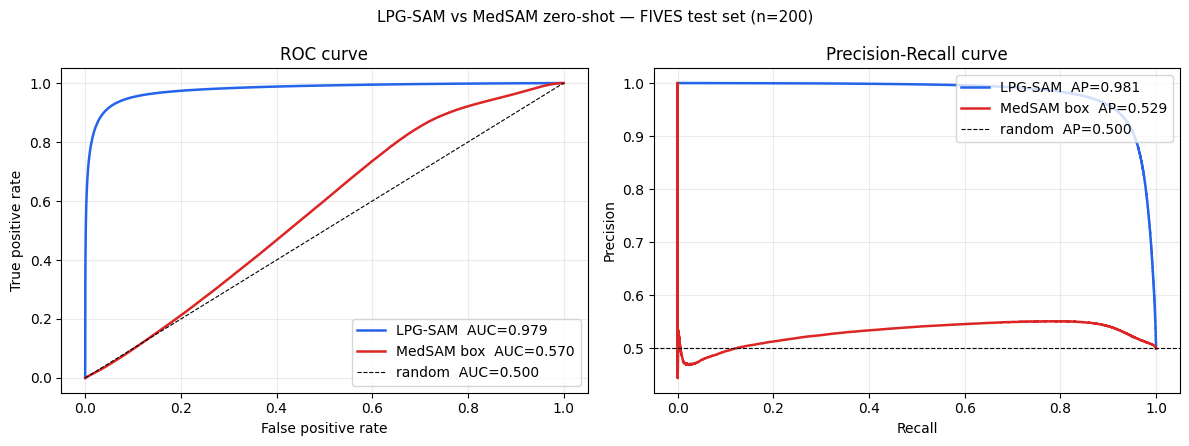

Saved → auc_curves_comparison.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 11 — AUC-ROC + AUC-PR (RAM-safe version)
#
# Key changes vs the crashing version:
#   1. Both models run in ONE loop — no double data loading
#   2. Stratified pixel subsampling (8 192 px/image instead of 1 048 576)
#      → final arrays are ~3 MB instead of ~800 MB each
#   3. Numpy arrays built incrementally and never duplicated
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import torch
import torch.nn.functional as F
import yaml
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
import matplotlib.pyplot as plt

from src.adapter import LatentPriorAdapter
from src.dataset import FundusVesselDataset
from src.sam_wrapper import FrozenSAM, SAM_INPUT_SIZE
from src.utils import get_device, seed_everything

# ── config ────────────────────────────────────────────────────────────────────
with open("configs/config.yaml") as f:
    cfg = yaml.safe_load(f)
seed_everything(cfg["train"]["seed"])
device = get_device()

# How many pixels to sample per image.
# 8 192 × 200 images = 1.6 M pixels → arrays are ~6 MB total. Accurate AUC.
PIXELS_PER_IMAGE = 8_192
rng = np.random.default_rng(42)

# ── dataset (batch_size=1 keeps GPU memory flat) ───────────────────────────────
ds = FundusVesselDataset(
    data_root  = "data/processed/FIVES",
    split_file = "data/processed/FIVES/test.txt",
    augment    = False,
    seed       = cfg["train"]["seed"],
)
loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"Test set: {len(ds)} images  |  device: {device}")

# ── models ────────────────────────────────────────────────────────────────────
print("\nLoading MedSAM backbone...")
sam = FrozenSAM(checkpoint_path=cfg["paths"]["sam_checkpoint"]).to(device)

print("Loading LPG-SAM adapter (checkpoints/best.pt)...")
adapter = LatentPriorAdapter(num_tokens=cfg["model"]["num_tokens"]).to(device)
ckpt    = torch.load("checkpoints/best.pt", map_location=device)
adapter.load_state_dict(ckpt["adapter_state_dict"])
adapter.eval()

# MedSAM box prompt — pre-built once, reused every image
box = torch.tensor([[[0., 0., SAM_INPUT_SIZE - 1, SAM_INPUT_SIZE - 1]]], device=device)

# ── single-pass collection ────────────────────────────────────────────────────
lpg_probs, med_probs, labels = [], [], []

@torch.no_grad()
def run():
    for batch in tqdm(loader, desc="AUC inference (both models)", ncols=90):
        image  = batch["image"].to(device, non_blocking=True)   # (1,3,H,W)
        frangi = batch["frangi"].to(device, non_blocking=True)  # (1,1,H,W)
        gt_np  = (batch["mask"].numpy()[0, 0] > 0.5)            # (H,W) bool, CPU

        # ── shared image encoding (only once per image) ───────────────────────
        z_image = sam.encode_image(image)  # (1,256,64,64)

        # ── LPG-SAM forward ───────────────────────────────────────────────────
        z_mod, sparse = adapter(z_image, frangi)
        dense  = sam.zero_dense_prompt(1, device)
        low, _ = sam.decode_masks(z_mod, sparse, dense, multimask_output=False)
        lpg_np = torch.sigmoid(F.interpolate(low, size=(SAM_INPUT_SIZE, SAM_INPUT_SIZE),
                               mode="bilinear", align_corners=False)
                               ).cpu().numpy()[0, 0]             # (H,W) float32

        # ── MedSAM box forward ────────────────────────────────────────────────
        sparse_b, dense_b = sam.sam.prompt_encoder(points=None, boxes=box, masks=None)
        low_b, _ = sam.decode_masks(z_image, sparse_b, dense_b, multimask_output=False)
        med_np = torch.sigmoid(F.interpolate(low_b, size=(SAM_INPUT_SIZE, SAM_INPUT_SIZE),
                               mode="bilinear", align_corners=False)
                               ).cpu().numpy()[0, 0]             # (H,W) float32

        # ── stratified pixel subsampling ──────────────────────────────────────
        # Sample PIXELS_PER_IMAGE/2 from each class so both models are compared
        # at the same operating points regardless of vessel prevalence.
        fg_idx = np.flatnonzero(gt_np)
        bg_idx = np.flatnonzero(~gt_np)
        half   = PIXELS_PER_IMAGE // 2

        fg_sample = rng.choice(fg_idx, size=min(half, len(fg_idx)), replace=False)
        bg_sample = rng.choice(bg_idx, size=min(half, len(bg_idx)), replace=False)
        idx = np.concatenate([fg_sample, bg_sample])

        lpg_probs.append(lpg_np.ravel()[idx])
        med_probs.append(med_np.ravel()[idx])
        labels   .append(gt_np .ravel()[idx])

        # Free GPU tensors immediately — don't let them accumulate across iters
        del z_image, z_mod, sparse, dense, low, lpg_np
        del sparse_b, dense_b, low_b, med_np
        torch.cuda.empty_cache()

run()

# ── build final arrays (small: ~6 MB total) ───────────────────────────────────
y_lpg   = np.concatenate(lpg_probs).astype(np.float32)
y_med   = np.concatenate(med_probs).astype(np.float32)
y_true  = np.concatenate(labels)
del lpg_probs, med_probs, labels   # free the lists

prevalence = y_true.mean()
print(f"\nSampled pixels : {len(y_true):,}  |  vessel prevalence: {100*prevalence:.1f}%")

# ── AUC ───────────────────────────────────────────────────────────────────────
res = {
    "LPG-SAM"   : {"auc_roc": roc_auc_score(y_true, y_lpg),
                   "auc_pr" : average_precision_score(y_true, y_lpg)},
    "MedSAM box": {"auc_roc": roc_auc_score(y_true, y_med),
                   "auc_pr" : average_precision_score(y_true, y_med)},
}

print("\n" + "─"*50)
print(f"{'Model':<14}  {'AUC-ROC':>9}  {'AUC-PR':>9}  {'rand AP':>9}")
print("─"*50)
for name, r in res.items():
    print(f"{name:<14}  {r['auc_roc']:>9.4f}  {r['auc_pr']:>9.4f}  {prevalence:>9.4f}")
print("─"*50)

# ── plot ──────────────────────────────────────────────────────────────────────
COLORS = {"LPG-SAM": "#2563eb", "MedSAM box": "#dc2626"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("LPG-SAM vs MedSAM zero-shot — FIVES test set (n=200)", fontsize=11)

for name, y_score in [("LPG-SAM", y_lpg), ("MedSAM box", y_med)]:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax1.plot(fpr, tpr, lw=1.8, color=COLORS[name],
             label=f"{name}  AUC={res[name]['auc_roc']:.3f}")
ax1.plot([0,1],[0,1], "k--", lw=0.8, label="random  AUC=0.500")
ax1.set_xlabel("False positive rate"); ax1.set_ylabel("True positive rate")
ax1.set_title("ROC curve"); ax1.legend(loc="lower right"); ax1.grid(alpha=0.25)

for name, y_score in [("LPG-SAM", y_lpg), ("MedSAM box", y_med)]:
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ax2.plot(rec, prec, lw=1.8, color=COLORS[name],
             label=f"{name}  AP={res[name]['auc_pr']:.3f}")
ax2.axhline(prevalence, color="k", ls="--", lw=0.8,
            label=f"random  AP={prevalence:.3f}")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall curve"); ax2.legend(loc="upper right"); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("auc_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → auc_curves_comparison.png")

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 12 — Frangi threshold baseline
#
# Uses the cached Frangi maps (data/processed/FIVES/frangi_cache/).
# No model. No GPU. Runs in ~30 seconds.
#
# Protocol:
#   1. Sweep thresholds on the VAL set → pick best clDice threshold
#   2. Report that threshold on the TEST set → fair comparison with LPG-SAM
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import yaml
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm import tqdm
from skimage.morphology import binary_closing, disk

from src.dataset import FundusVesselDataset
from src.metrics import MetricAccumulator
from src.utils import seed_everything

with open("configs/config.yaml") as f:
    cfg = yaml.safe_load(f)
seed_everything(cfg["train"]["seed"])

CLOSING_RADIUS  = cfg["eval"].get("closing_radius", 0)
THRESHOLDS      = np.arange(0.05, 0.96, 0.05).tolist()   # 19 candidates

# ── datasets ──────────────────────────────────────────────────────────────────
def make_loader(split_file, batch_size=4):
    ds = FundusVesselDataset(
        data_root  = "data/processed/FIVES",
        split_file = split_file,
        augment    = False,
        seed       = cfg["train"]["seed"],
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=2, pin_memory=False)

val_loader  = make_loader("data/processed/FIVES/val.txt")
test_loader = make_loader("data/processed/FIVES/test.txt")

# ── scoring helper ────────────────────────────────────────────────────────────
def score_frangi(loader, threshold, desc=""):
    acc = MetricAccumulator()
    for batch in loader:
        frangi = batch["frangi"].numpy()   # (B,1,H,W) float32 in [0,1]
        gt     = batch["mask"].numpy()     # (B,1,H,W) float32
        names  = batch["name"]
        for b in range(frangi.shape[0]):
            pred = frangi[b, 0] > threshold
            if CLOSING_RADIUS > 0:
                pred = binary_closing(pred, footprint=disk(CLOSING_RADIUS))
            gt_b = gt[b, 0] > 0.5
            acc.update(pred, gt_b, name=names[b])
    return acc

# ── threshold sweep on VAL ────────────────────────────────────────────────────
print("Sweeping thresholds on val set...")
print(f"{'Threshold':>10}  {'Dice':>7}  {'IoU':>7}  {'clDice':>8}  {'B0err':>8}")
print("─" * 50)

best_cldice, best_thresh = -1, None
for t in tqdm(THRESHOLDS, desc="threshold sweep", ncols=70):
    acc = score_frangi(val_loader, threshold=t)
    s   = acc.summary()
    marker = "  ←" if s["cldice"] > best_cldice else ""
    print(f"  t={t:.2f}      {s['dice']:.4f}  {s['iou']:.4f}  "
          f"{s['cldice']:.4f}  {s['betti0_error']:8.2f}{marker}")
    if s["cldice"] > best_cldice:
        best_cldice  = s["cldice"]
        best_thresh  = t

print(f"\n→ Best val threshold: {best_thresh:.2f}  (val clDice={best_cldice:.4f})")

# ── evaluate on TEST with best threshold ──────────────────────────────────────
print(f"\nEvaluating on test set at threshold={best_thresh:.2f} ...")
test_acc = score_frangi(test_loader, threshold=best_thresh, desc="test")
s = test_acc.summary()

print("\n" + "=" * 50)
print(f"  Frangi threshold baseline  (t={best_thresh:.2f})")
print("=" * 50)
print(f"  n samples  : {s['n']}")
print(f"  Dice       : {s['dice']:.4f}")
print(f"  IoU        : {s['iou']:.4f}")
print(f"  clDice     : {s['cldice']:.4f}    <- headline metric")
print(f"  Betti-0 err: {s['betti0_error']:.2f}")
print("=" * 50)


Sweeping thresholds on val set...
 Threshold     Dice      IoU    clDice     B0err
──────────────────────────────────────────────────


threshold sweep:   5%|▉                | 1/19 [00:21<06:26, 21.48s/it]

  t=0.05      0.1969  0.1097  0.2164     21.97  ←


threshold sweep:  11%|█▊               | 2/19 [00:36<05:03, 17.88s/it]

  t=0.10      0.2533  0.1458  0.2286   1129.88  ←


...

threshold sweep:  95%|███████████████▏| 18/19 [03:47<00:11, 11.25s/it]

  t=0.90      0.0002  0.0001  0.0001    147.58


threshold sweep: 100%|████████████████| 19/19 [03:57<00:00, 12.48s/it]

  t=0.95      0.0001  0.0000  0.0000    117.48

→ Best val threshold: 0.15  (val clDice=0.2828)

Evaluating on test set at threshold=0.15 ...



  Frangi threshold baseline  (t=0.15)
  n samples  : 200
  Dice       : 0.3129
  IoU        : 0.1932
  clDice     : 0.2840    <- headline metric
  Betti-0 err: 4872.30
